# **Lecture 26: Applications in Astrophysics - Hydrodynamics**

**Course:** Computational Astrophysics (PHYS 8202)

**Topic:** Eulerian vs Lagrangian Perspectives, Advection, and Finite Difference Schemes

***

## **1. Introduction to Astrophysical Fluid Dynamics**

Much of the visible universe is composed of gas and plasma. Whether we are studying the collapse of a molecular cloud, the accretion disk around a black hole, or the explosive shockwave of a supernova, we cannot treat the system as a collection of discrete N-bodies. There are simply too many particles.

Instead, we treat the macroscopic system as a continuous fluid. This requires us to solve the equations of Hydrodynamics, which are fundamentally based on the conservation of mass, momentum, and energy.


### **Exam Concept: Control Volume vs. Control Mass**

Before we can write code, we must choose a mathematical framework to describe our fluid. There are two primary perspectives in hydrodynamics:

**1. The Lagrangian Perspective (Control Mass)**
* **Definition:** We define a specific "packet" or mass of fluid and track it as it moves through space and time.
* **Analogy:** Sitting in a boat and floating down a river, measuring the water's properties as you move with the current.
* **Computational Use:** Smoothed Particle Hydrodynamics (SPH), which is excellent for tracking galaxy collisions and empty space.

**2. The Eulerian Perspective (Control Volume)**
* **Definition:** We define a fixed volume in space (a grid cell) and measure the fluid as it flows in and out of this static boundary over time.
* **Analogy:** Standing on a bridge and watching the river flow past a specific point, measuring the velocity of whatever water happens to be beneath you at that moment.
* **Computational Use:** Grid-based codes (Finite Difference/Finite Volume), which are the standard for capturing sharp shockwaves like supernovas.


## **2. The Advection Equation & Supernova Challenges**

The simplest possible hydrodynamic equation is the 1D Advection Equation. It describes a quantity (like fluid density $\rho$) being transported by a velocity field $v$.

$$\frac{\partial\rho}{\partial t} + v\frac{\partial\rho}{\partial x} = 0$$

**Computational Challenges in Supernova Simulations:**
Simulating an event like a supernova explosion using explicit Eulerian finite difference schemes is notoriously difficult due to extreme gradients. 
1.  **Shock Fronts:** Supernovas create discontinuities where density and pressure jump to near-infinity across a single grid cell. Standard finite difference schemes fail here, producing unphysical oscillations (ringing) that crash the simulation.
2.  **The Courant Condition (CFL Limit):** Information in an explicit grid cannot travel faster than one grid cell per time step. For a supernova with extreme expansion velocities ($v$), the time step $\Delta t$ must become infinitesimally small to prevent the simulation from exploding computationally, leading to massive computational expense.


## **3. Numerical Schemes: The Lax-Friedrichs Method**

If we attempt to solve the advection equation using the most obvious approach (Forward in Time, Centered in Space, or FTCS), the code will immediately become unconditionally unstable. The wave will amplify to infinity.

To fix this, we introduce **Numerical Viscosity**. The **Lax-Friedrichs Scheme** achieves stability by replacing the current time-step value $u_i^n$ with a spatial average of its neighbors.

**The Lax-Friedrichs Discretization:**
$$u_i^{n+1} = \frac{1}{2}(u_{i+1}^n + u_{i-1}^n) - \frac{v \Delta t}{2 \Delta x} (u_{i+1}^n - u_{i-1}^n)$$

Let us write a Python script to implement this scheme for a planetary atmospheric wave.

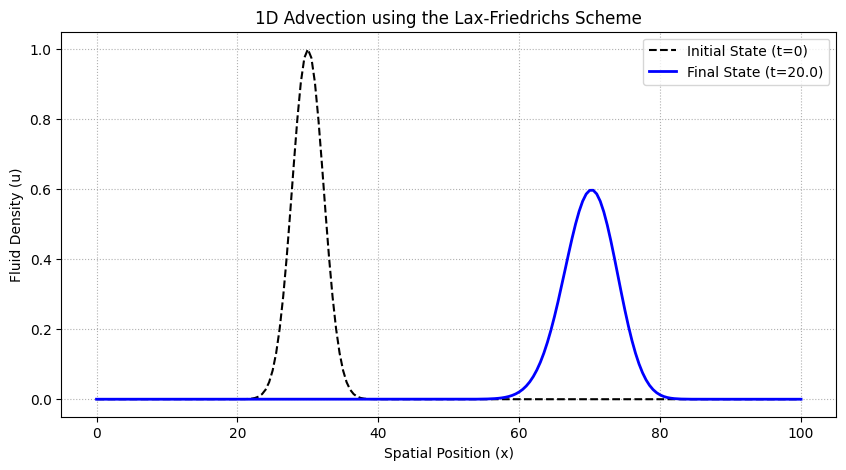

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup the Grid and Parameters
L = 100.0           # Length of the 1D domain
nx = 201            # Number of spatial grid points
dx = L / (nx - 1)   # Spatial step size
x = np.linspace(0, L, nx)

v = 2.0             # Constant advection velocity
t_final = 20.0      # Total simulation time

# 2. The Courant-Friedrichs-Lewy (CFL) Condition
# For stability in Lax-Friedrichs, the Courant number (C) must be <= 1.0
C = 0.8
dt = C * dx / v     # Calculate stable time step
nt = int(t_final / dt)

# 3. Initial Conditions (A Gaussian density pulse)
u_initial = np.exp(-0.1 * (x - 30.0)**2)
u = u_initial.copy()
u_next = np.zeros(nx)

# 4. The Lax-Friedrichs Time Integration Loop
for n in range(nt):
    # Update internal grid points using the explicit scheme
    for i in range(1, nx - 1):
        spatial_average = 0.5 * (u[i+1] + u[i-1])
        advection_term = (v * dt / (2.0 * dx)) * (u[i+1] - u[i-1])
        u_next[i] = spatial_average - advection_term
        
    # Periodic Boundary Conditions (Wave wraps around the edges)
    u_next[0] = 0.5 * (u[1] + u[-2]) - (v * dt / (2.0 * dx)) * (u[1] - u[-2])
    u_next[-1] = u_next[0]
    
    # Advance time
    u[:] = u_next[:]

# 5. Visualization
plt.figure(figsize=(10, 5))
plt.plot(x, u_initial, 'k--', label='Initial State (t=0)')
plt.plot(x, u, 'b-', lw=2, label=f'Final State (t={t_final})')
plt.title('1D Advection using the Lax-Friedrichs Scheme')
plt.xlabel('Spatial Position (x)')
plt.ylabel('Fluid Density (u)')
plt.legend()
plt.grid(True, linestyle=':')
plt.show()


### **Notice the Amplitude Drop**
When you run the code above, you will notice that the final blue wave has traveled to the right correctly, but it is shorter and wider than the initial black wave. 

This is the cost of the Lax-Friedrichs scheme. The spatial averaging term ($0.5(u_{i+1} + u_{i-1})$) acts like diffusion. It smears the wave out over time. In advanced astrophysics codes, we use higher-order methods (like the Upwind Scheme or TVD limiters) to advect shocks without smearing them.